## BLAS-ified *C*-Support Vector Classifiers
*ph 27-03-2025*

### Introduction

Taking advantage of Basic Linear Algebra Subprograms (BLAS) libraries can be an ace up the sleeve of the savvy scientist. While you could manually implement SIMD intrinsics or rely on compiler auto-vectorization (if your compiler is smart enough, it often isn't), using BLAS often both simplifies your code and makes extending to a variety of CPU, GPU, or NPU targets much easier.

In this notebook, we'll take a practical look at how you can use some lesser known linear algebra, namely the [Hadamard](https://en.wikipedia.org/wiki/Hadamard_product_(matrices)) (element-wise) product, in order to directly derive a BLAS-friendly version of a well known model in supervised pattern recognition and classification: the *C*-Support Vector Classifier (*C*-SVC). In fact, this quirky derivation actually ends up a lot simpler than you'd otherwise have to deal with when using sums, given you stick closely to the matrix structure of the data. To keep things from getting too long, we utilize the convex optimization library [cvxpy](https://www.cvxpy.org/) instead of our own solver (SMO or otherwise).

As a final word of caution: this notebook is best followed with an existing understanding of Support Vector Machines (SVMs) and convex optimization. This is mainly for students who struggle with implementing algorithms with BLAS, and the derivation given here is esoteric and not something I've seen elsewhere. Consider the concise overview provided by [1] as a refresher of the motivation behind SVMs and see [2], [3], or [4] for more thorough treatment of max-margin models.


[1] https://scikit-learn.org/stable/modules/svm.html#mathematical-formulation

[2] Christopher M. Bishop, Pattern Recognition and Machine Learning, Springer, 2006.

[3] https://cs229.stanford.edu/main_notes.pdf

[4] https://www.csd.uwo.ca/~xling/cs860/papers/SVM_Explained.pdf

### Datasets
A natural starting point for a classification problem would be to consider the structure of our datasets.

In some texts, such as in section 8.6 of Boyd [5] (a classic convex optimization book!), we're given two sets of points in $\mathbb{R}^n$, $\{a_1,\dots,a_L\}$ and $\{b_1,\dots,b_M\}$ we want to discriminate. What would our solution look like? Consider a function $f : \mathbb{R}^n \to \mathbb{R}$ that's positive on the first set and negative on the second. The 0-level set of $f$, $\{ x | f(x) = 0 \}$, then discriminates (a.k.a. separates, classifies) the data.
$$
f(a_i) > 0,\quad i = 1,\dots,L, \qquad f(b_i) < 0,\quad i = 1, \dots ,M.
$$

This way of organizing data is unusual in machine learning. Instead, we can describe our dataset $d = (x, y)$ as the ordered pair of samples $ x = a \cup b$ and labels:
$$
y_i = \left\{ \begin{array}{ll} 1 & x_i \in a \\ -1 & x_i \in b \end{array} \right.
$$
for $i = 1,\dots,N$. Note that number of points in our set is $N = L + M$. In other words, $\{ d \in \mathbb{R}^{n \times N} \times \mathbb{R}^{N} : d = x \times 1 \cup y \times -1 \}$, where $\times$ denotes the cartesian product. Choosing $1$ and $-1$ makes the formulation we'll develop simpler. With that out of the way, let's begin by importing the libraries and dataset we'll use.

*Note: you might have noticed that the shape of $x$ in the code seems off. Instead of a matrix of n (the dimension) rows and N (the number of points) columns, we get the transpose, $x^T$. All this does is make the code slightly simpler, and I've included comments noting changes where appropriate. So don't worry about it :)*


[5] Stephen Boyd, Convex Optimization, 2009.

Shape of x: (row, col) = (100, 2)
Shape of y: (row, col) = (100,)


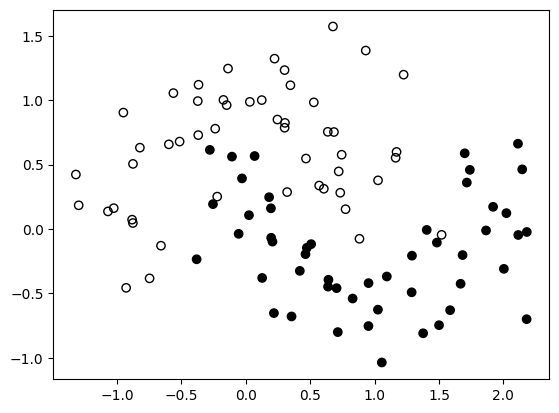

In [1]:
import matplotlib.pyplot as plt
import cvxpy as cp
import numpy as np
from sklearn import datasets

# iris = datasets.load_iris()
# X, y = iris.data[:, :2], iris.target
X, y = datasets.make_moons(noise=0.3, random_state=0)

# Convert labels
y = np.array([1 if i > 0 else -1 for i in y])

# Notice anything?
print(f"Shape of x: (row, col) = {X.shape}")
print(f"Shape of y: (row, col) = {y.shape}")

# Plot the data
fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], color="k", facecolors=np.where(y == 1, "k", "none"))
plt.show()

### The Optimization Problem

While there there are a number of ways of formulating an SVM (such as the "standard support vector classifier" presented in [5]), a common one is the *C*-SVC [6] as implemented in scikit-learn [1]. With decision boundary $f(x) = w^T\phi(x) + b$ and regularization hyperparameter $C > 0$:
$$
\begin{array}{ll}
\displaystyle \min_{w, b, \zeta} & \frac{1}{2}||w||_2^2 + C \sum^{N}_{i=1}{\zeta_i} \\
\text{s.t. }
& y_i(w^T\phi(x_i) + b) \ge 1-\zeta_i, \qquad i = 1, \dots, N \\
& \zeta \succcurlyeq 0 \\
\end{array}
$$
Recall our dimensions: $w \in \mathbb{R}^{n}$ and $y, \zeta \in \mathbb{R}^{N}$. Note that $\sum^{N}_{i=1} \zeta_i$ is the sum of all elements of $\zeta$, equivalent to $\mathbf{1}^T\zeta$ or dot product $\mathbf{1} \cdot \zeta$ (where $\mathbf{1}$ is an *N*-vector with all elements equal to 1).

Using squared $L^2$-norm $||w||_2^2 = w^Tw$ as the margin (i.e. slab width) term gives us a quadratic program (the half term is aesthetic for when we formulate the dual problem). The function $\phi(x_i) : \mathbb{R}^n \mapsto \mathbb{R}^D$ is a generalization of the nonlinear classifier introduced in section 8.6.2 of Boyd, 2009 [5], allowing us to project the data into some higher dimensional feature space $D > n$. For a linear classifier, $\phi(x_i) = x_i$ is the identity function. Let's begin by implementing a linear *C*-SVC and verifying equivalence with the scikit-learn version.


[6] Chih-Chung Chang and Chih-Jen Lin, LIBSVM : a library for support vector machines. ACM Transactions on Intelligent Systems and Technology, 2:27:1--27:27, 2011.

slope: 0.6357776890437001, bias: -0.10444375765743683


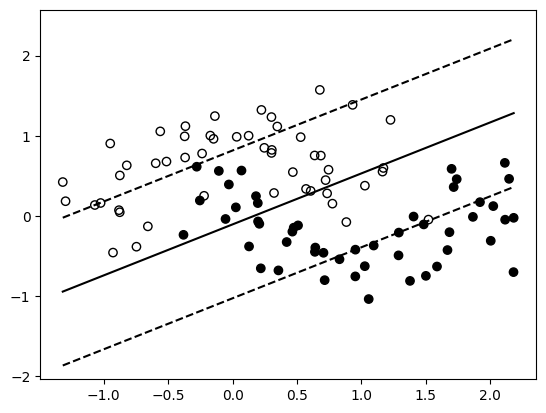

In [2]:
def csvc_lin(data, labels, C):
    zeta = cp.Variable(data.shape[0])
    w = cp.Variable(data.shape[1])
    b = cp.Variable()
    objective = cp.Minimize((1 / 2) * (cp.norm(w, 2) ** 2) + C * cp.sum(zeta))
    constraints = [cp.multiply(labels, data @ w + b) >= 1 - zeta, zeta >= 0]
    # Alternatively, you could do:
    # x = data.T
    # constraints = [cp.multiply(labels, w.T @ x + b) >= 1 - zeta, zeta >= 0]

    prob = cp.Problem(objective, constraints)
    prob.solve()
    # print(f"Problem Status: {prob.status}")
    return w.value, b.value, zeta.value


w, b, zeta = csvc_lin(X, y, 0.1)

# 0-Level Set (i.e. separating line):
# 0 = w.T * x - b
# x[1] = (-w[0] * x[0] - b ) / w[1]
print(f"slope: {-w[0] / w[1]}, bias: {-b / w[1]}")

fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], color="k", facecolors=np.where(y == 1, "k", "none"))
x_min = np.min(X[:, 0])
x_max = np.max(X[:, 0])


def line(x, w, b):
    return (-w[0] * x - b) / w[1]


ax.plot([x_min, x_max], [line(x_min, w, b), line(x_max, w, b)], "k-")
ax.plot([x_min, x_max], [line(x_min, w, b + 1), line(x_max, w, b + 1)], "k--")
ax.plot([x_min, x_max], [line(x_min, w, b - 1), line(x_max, w, b - 1)], "k--")
ax.set_ylim((np.min(X[:, 1]) - 1, np.max(X[:, 1]) + 1))
plt.show()

In [3]:
from sklearn import svm

clf = svm.SVC(kernel="linear", C=0.1)
clf.fit(X, y)
print(
    f"slope: {-clf.coef_[0][0] / clf.coef_[0][1]}, bias: {-clf.intercept_[0] / clf.coef_[0][1]} (sklearn)"
)

slope: 0.635778233158064, bias: -0.10444370198524515 (sklearn)


### The Dual Problem

At this point, we have enough theory to start tackling non-linear classification. However, let's take a look at the dual form of the problem to see if we can make any improvements. Beginning with our *C*-SVC formulation:
$$
\begin{array}{ll}
\displaystyle \min_{w, b, \zeta} & \frac{1}{2}w^Tw + C(\mathbf{1}^T\zeta) \\
\text{s.t. }
& y \odot f(x)^T \succcurlyeq \mathbf{1} - \zeta\\
& \zeta \succcurlyeq 0 \\
\end{array}
$$

Where $\odot$ is the Hadamard product. Be careful here and take note of the structure of our elements: $f(x)$ is transposed as it's effectively an $n$-column $N$-row matrix, while $y$ and $\zeta$ are $N$-column vectors. Since Slater's condition holds and we have inequality constraints, we use the [Karush-Kuhn-Tucker](https://en.wikipedia.org/wiki/Karush%E2%80%93Kuhn%E2%80%93Tucker_conditions) (KKT) method of Lagrange multipliers to derive the dual problem. The Lagrangian is:
$$
\mathcal{L} = \frac{1}{2}w^Tw + C(\mathbf{1}^T\zeta) + \alpha^T(\mathbf{1} - \zeta - y \odot f(x)^T) - \mu^T\zeta
$$
The primal feasibility conditions are:
$$
y \odot f(x)^T - (\mathbf{1} - \zeta) \succcurlyeq 0 \\
\zeta \succcurlyeq 0
$$
The dual feasibility conditions are:
$$
\alpha, \mu \succcurlyeq 0 \tag{1}
$$
The stationarity conditions are:
$$
\frac{\partial \mathcal{L}}{\partial w} = 0 \Rightarrow \phi(x)(\alpha \odot y) = w \tag{2}
$$
$$
\frac{\partial \mathcal{L}}{\partial b} = 0 \Rightarrow \alpha^Ty = 0 \tag{3}
$$
$$
\frac{\partial \mathcal{L}}{\partial \zeta} = 0 \Rightarrow \alpha + \mu = C\mathbf{1} \tag{4}
$$
The complementary conditions are:
$$
\mu \odot \zeta =\mathbf{0} \tag{5}
$$
$$
\alpha \odot (\mathbf{1} - \zeta - y \odot f(x)^T) = \mathbf{0} \tag{6}
$$
By substituting $(3)$, $(4)$, and the discriminant function into the Lagrangian and eliminating $w$ by substituting $(2)$, we obtain:
$$
\mathcal{L} = \frac{1}{2}w^Tw + (\alpha + \mu)^T\zeta + \alpha^T\mathbf{1} - \alpha^T\zeta - \alpha^T(y \odot f(x)^T) - \mu^T\zeta \\
\mathcal{L} = \mathbf{1}^T\alpha + \frac{1}{2}w^Tw - (\alpha \odot y)^T (w^T \phi(x))^T \\
\mathcal{L} = \mathbf{1}^T\alpha + \frac{1}{2}(\phi(x)(\alpha \odot y))^T\phi(x)(\alpha \odot y) - (\alpha \odot y)^T ((\phi(x)(\alpha \odot y))^T \phi(x))^T \\
\mathcal{L} = \mathbf{1}^T\alpha + \frac{1}{2}(\alpha \odot y)^T\phi(x)^T\phi(x)(\alpha \odot y) - (\alpha \odot y)^T \phi(x)^T \phi(x) (\alpha \odot y) \\
\mathcal{L} = \mathbf{1}^T\alpha - \frac{1}{2}(\alpha \odot y)^T\phi(x)^T\phi(x)(\alpha \odot y)
$$

To make computing this easier, let's separate dual variables and the given data, which we can precompute:
$$
\mathcal{L} = \mathbf{1}^T\alpha - \frac{1}{2}\alpha^T((yy^T) \odot K)\alpha
$$
Where $yy^T = y \otimes y$ is an outer product, and $K$ is the [Gramian](https://en.wikipedia.org/wiki/Gram_matrix) of $\phi$:
$$
K_{i j} = \langle\phi(x_i),\phi(x_j)\rangle
$$

Compare the above with what you might typically see in literature (see 6.6 of [3] for example). Which do you think would be easier to vectorize?
$$
\mathcal{L} = \sum_{i=1}^{N} \alpha_i - \frac{1}{2} \sum_{i=1}^{N} \sum_{j=1}^{N} \alpha_i \alpha_j y_i y_j K(x_i,x_j) \tag{2}
$$

Note that [it can be shown that](https://en.wikipedia.org/wiki/Definite_matrix#Decomposition) our Gramian $K$ must be symmetric positive-semidefinite (PSD) (you can consider this the reverse of the [Cholesky decomposition](https://en.wikipedia.org/wiki/Cholesky_decomposition#Positive_semidefinite_matrices)):
$$
K^T = (\phi^T\phi)^T = \phi^T\phi = K \\
v^TKv = v^T \phi^T\phi v = (\phi v)^T \phi v = ||\phi v||^2_2 \ge 0
$$

Herein lies the so called "kernel trick": the implicit definition of $\phi$ through the kernel allows us to skip the step of actually defining the feature space $\phi$, as long as we pick a kernel that is symmetric PSD (since it always corresponds to some $\phi$). We'll avoid diving further into functional analysis here, but the generalization of this is [Mercer's theorem](https://en.wikipedia.org/wiki/Mercer's_theorem). Note that this makes our optimization a convex quadratic program which is convenient to implement with cvxpy (production algorithms are more involved, see [7]).

Importantly, avoiding explicitly computing $\phi(x)$ by just calculating the kernel matrix $K$ directly makes our parameter count independent of the projection, sidestepping the curse of dimensionality.

For our purposes I have implemented three common kernels, including the radial basis function (a.k.a. "Gaussian") kernel with an infinite-dimensional feature space. Another popular kernel is the sigmoid (tanh), but this presents additional problems with positive semi-definiteness and convexity as described in section 2.3 of [7]. For further discussion on constructing kernels, see section 6.2 of [2].
$$
K(x_i, x_j)_{lin} = \langle x_i,x_j \rangle
$$
$$
K(x_i, x_j)_{poly} = (\langle x_i,x_j \rangle + 1)^p
$$
$$
K(x_i, x_j)_{rbf} = \displaystyle \exp(-\gamma||x_i-x_j||_2^2)
$$


Continuing on, from $(4)$ and $(1)$ we obtain the inequality $0 \preccurlyeq \alpha \preccurlyeq C$. We therefore have our dual problem:
$$
\begin{array}{ll}
\displaystyle \max_{\alpha} & \mathbf{1}^T\alpha - \frac{1}{2}\alpha^TQ\alpha \\
\text{s.t. }
& y^T\alpha = 0, \\
& 0 \preccurlyeq \alpha \preccurlyeq C \\
\end{array} \\
Q = (y \otimes y) \odot K \\
$$

A question remains: how do we recover the classifier? Let's begin with the bias (i.e. intercept). Through $(1)$, $(4)$, $(5)$, and $(6)$, we have:
$$
\left\{ \begin{array}{ll} y_if(x_i) \ge 1 & \alpha_i = 0 \\ y_if(x_i) \le 1 & \alpha_i = C \\ y_if(x_i) = 1 & 0 < \alpha_i < C \end{array} \right. \tag{7}
$$
Taking the last condition and substituting the decision function, we have for set $S = \{ j : 0 < \alpha_i < C \}$:
$$
b = y_j - w^T\phi(x_j) \forall j \\
$$
Since we are solving the dual problem, there is a more convenient equivalent form for $b$ we can obtain by substituting $(2)$ and rearranging:
$$
b = y_j(1 - (Q\alpha)_j) \forall j \\
$$

As per [6] we take the mean of the intercepts for numerical stability (note that for for empty $S$, the process is slightly different: starting from $(7)$ we take the median of when $\alpha = 0$ or $\alpha = C$. See the code for details):
$$
b = \frac{1}{|S|}\sum_{j \in S} y_j(1 - (Q\alpha)_j)
$$

Finally, to find the classifier we substitute $(2)$ into the decision function:
$$
f(x) = (\phi(x)(\alpha \odot y))^T\phi(x) + b \\
f(x) = (\alpha \odot y)^T\phi(x)^T\phi(x) + b \\
f(x) = (\alpha \odot y)^T K + b
$$
The second key insight behind SVMs lies here: because $\alpha$ is sparse, to classify points we only need to sum across the support vectors.
$$
f(x) = (\alpha \odot y_{sv})^T K(x_{sv}, x) + b \\
\{ sv \in \alpha : sv > 0 \}
$$

Equivalent to:
$$
f(x) = \sum_{i \in \alpha > 0}\alpha_i y_i K(x_i, x) + b
$$

Let's try out our implementation. Support vectors are highlighted in red.


[7] https://www.dcsc.tudelft.nl/~mohajerin/Publications/conference/2024/IO_Kernel.pdf

In [4]:
def lin_kern(x1, x2, param):
    # Param is unused in the linear kernel
    # Since data is transposed instead of np.dot(x1, x2) = x1.T @ x2 we have np.inner(x1, x2) = np.dot(x1, x2.T)
    return np.inner(x1, x2)


def poly_kern(x1, x2, param):
    return np.power(np.inner(x1, x2) + 1, param)


def rbf_kern(x1, x2, param):
    return np.exp(-param * (np.linalg.norm((x1[:, None] - x2[None, :]), 2, 2) ** 2))


def csvc(data, labels, kernel, param, C):
    # Error bound for numerical inaccuracies
    eps = 1e-8

    # Calculate kernel matrix
    K = kernel(data, data, param)
    if not np.allclose(K, K.T) or np.any(np.linalg.eigvals(K) < 0):
        # print("Warning: Gramian not symmetric/positive semi-definite, regularizing...")
        K = (K + K.T) / 2
        K = K + eps * np.eye(K.shape[0])
    Q = np.outer(labels, labels) * K

    # Formulate quadratic program
    alpha = cp.Variable(data.shape[0])
    objective = cp.Maximize(
        cp.sum(alpha) - (1 / 2) * cp.quad_form(alpha, cp.psd_wrap(Q))
    )
    constraints = [labels.T @ alpha == 0, alpha >= 0, alpha <= C]

    problem = cp.Problem(objective, constraints)
    problem.solve()
    # print(f"Problem Status: {problem.status}")

    # Calculate bias (i.e. intercept)
    S = (alpha.value > eps) & (alpha.value < C - eps)
    # This might throw divide by zero warnings, but we don't care since those values are unused
    Qa = np.matmul(alpha.value, Q)
    if np.any(S):
        b = np.mean(labels[S] * (1 - Qa[S]))
    else:
        S1 = np.ma.mask_or(
            (alpha.value <= eps) & (labels == 1),
            (alpha.value >= C - eps) & (labels == -1),
        )
        S2 = np.ma.mask_or(
            (alpha.value <= eps) & (labels == -1),
            (alpha.value >= C - eps) & (labels == 1),
        )
        b = np.median(
            [
                np.max(labels[S1] * (1 - Qa[S1])),
                np.min(labels[S2] * (1 - Qa[S2])),
            ]
        )

    # Support vectors and associated dual variables
    alpha_sv = alpha.value[alpha.value > eps]
    sv = data[alpha.value > eps]
    sv_labels = labels[alpha.value > eps]

    return alpha_sv, sv, sv_labels, b, kernel, param


def classifier(data, alpha, sv, sv_labels, b, kernel, param):
    # Since data is transposed we have kernel(data, sv, param) = kernel(sv, data, param).T
    return np.sign(np.inner(alpha * sv_labels, kernel(data, sv, param)) + b)

Linear kernel:


/var/folders/_q/vt7xc8vj1pz09h8gvkgp7k740000gn/T/ipykernel_13735/4160670390.py:41: RuntimeWarning: divide by zero encountered in matmul
  Qa = np.matmul(alpha.value, Q)
/var/folders/_q/vt7xc8vj1pz09h8gvkgp7k740000gn/T/ipykernel_13735/4160670390.py:41: RuntimeWarning: overflow encountered in matmul
  Qa = np.matmul(alpha.value, Q)
/var/folders/_q/vt7xc8vj1pz09h8gvkgp7k740000gn/T/ipykernel_13735/4160670390.py:41: RuntimeWarning: invalid value encountered in matmul
  Qa = np.matmul(alpha.value, Q)


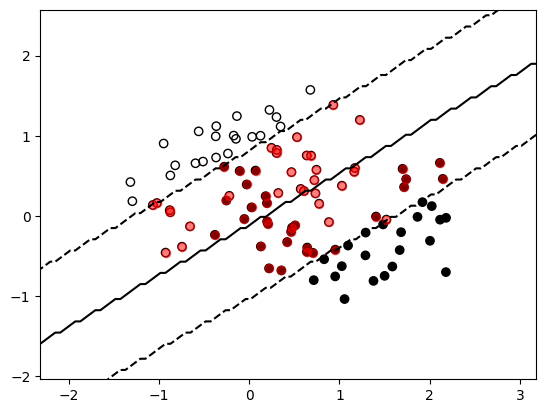

Quintic Poly kernel:


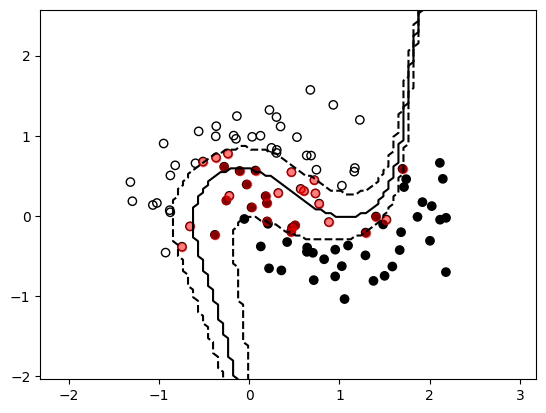

RBF kernel:


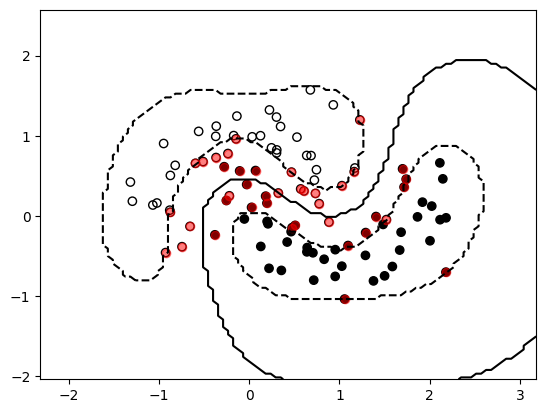

In [5]:
def plot_classifier(data, labels, alpha, sv, sv_labels, b, kernel, param):
    # This function is very hacky, c'est la vie
    fig, ax = plt.subplots()
    xx, yy = np.meshgrid(
        np.linspace(np.min(data[:, 0]) - 1, np.max(data[:, 0]) + 1, 100),
        np.linspace(np.min(data[:, 1]) - 1, np.max(data[:, 1]) + 1, 100),
    )
    ax.scatter(
        data[:, 0], data[:, 1], color="k", facecolors=np.where(labels == 1, "k", "none")
    )
    ax.scatter(sv[:, 0], sv[:, 1], color="r", alpha=0.5)
    X = np.c_[xx.ravel(), yy.ravel()]
    Z = classifier(X, alpha, sv, sv_labels, b, kernel, param).reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[0], colors=["k"])
    Z = classifier(X, alpha, sv, sv_labels, b - 1, kernel, param).reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[0], colors=["k"], linestyles=["dashed"])
    Z = classifier(X, alpha, sv, sv_labels, b + 1, kernel, param).reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[0], colors=["k"], linestyles=["dashed"])
    ax.set_ylim((np.min(data[:, 1]) - 1, np.max(data[:, 1]) + 1))
    plt.show()


print("Linear kernel:")
plot_classifier(X, y, *csvc(X, y, kernel=lin_kern, param=0, C=0.1))

print("Quintic Poly kernel:")
plot_classifier(X, y, *csvc(X, y, kernel=poly_kern, param=5, C=0.1))

print("RBF kernel:")
plot_classifier(X, y, *csvc(X, y, kernel=rbf_kern, param=1, C=1))

Linear kernel:


/var/folders/_q/vt7xc8vj1pz09h8gvkgp7k740000gn/T/ipykernel_13735/4160670390.py:41: RuntimeWarning: divide by zero encountered in matmul
  Qa = np.matmul(alpha.value, Q)
/var/folders/_q/vt7xc8vj1pz09h8gvkgp7k740000gn/T/ipykernel_13735/4160670390.py:41: RuntimeWarning: overflow encountered in matmul
  Qa = np.matmul(alpha.value, Q)
/var/folders/_q/vt7xc8vj1pz09h8gvkgp7k740000gn/T/ipykernel_13735/4160670390.py:41: RuntimeWarning: invalid value encountered in matmul
  Qa = np.matmul(alpha.value, Q)


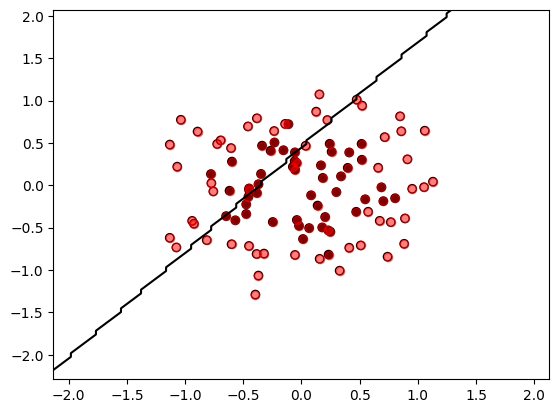

Quadratic Poly kernel (circles):


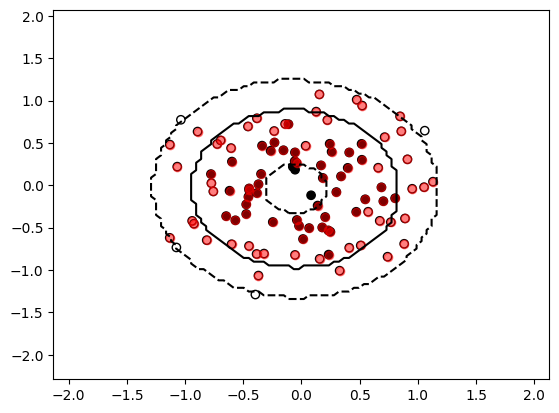

RBF kernel (circles):


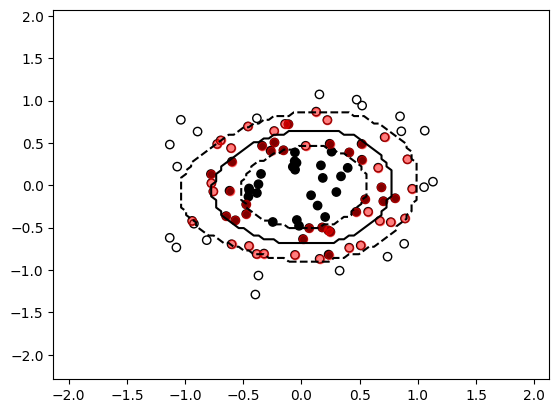

In [ ]:
X, y = datasets.make_circles(noise=0.2, factor=0.5, random_state=1)
y = np.array([1 if i > 0 else -1 for i in y])

print("Linear kernel (circles):")
plot_classifier(X, y, *csvc(X, y, kernel=lin_kern, param=0, C=0.1))

print("Quadratic Poly kernel (circles):")
plot_classifier(X, y, *csvc(X, y, kernel=poly_kern, param=2, C=0.1))

print("RBF kernel (circles):")
plot_classifier(X, y, *csvc(X, y, kernel=rbf_kern, param=1, C=1))